<a href="https://colab.research.google.com/github/rebecapaes/MVP-posgrad-analise-dados/blob/main/MVP_An%C3%A1liseDeDados_RebecaPaes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas :

**Nome:** Rebeca Esteves de Lima Paes

**Matrícula:** 405202502290

**Datasets:**
1. Fabric Properties and Suitability Dataset\
[link no kaggle](https://www.kaggle.com/datasets/nadeeshaniekanayaka/fabric-properties-and-suitability-dataset)\
[link no meu github](https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-analise-dados/refs/heads/main/Fabric%20Properties%20and%20Suitability%20Dataset.csv)

2. Sustainable Fashion: Eco-Friendly Trends\
[link no kaggle](https://www.kaggle.com/datasets/waqi786/sustainable-fashion-eco-friendly-trends)\
[link no meu github](https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-analise-dados/refs/heads/main/sustainable_fashion_trends_2024.csv)

# O Problema:
- Descrição
- Hipóteses
- Tipo

## Descrição do Problema:

Entender, a partir de dois datasets distintos, a evolução de melhorias no impacto ambiental na indústria têxtil ao redor do mundo.

Para isso utilizei o dataset "Fabric Properties and Suitability Dataset" (abreviado no presente projeto para "Properties"), que fornece dados técnicos da estrutura dos tecidos, e o dataset Sustainable Fashion: Eco-Friendly Trends (abreviado para "Sustainable"), que fornece dados relacionados ao impacto ambiental de cada material em cada país ao longo do tempo.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Alguns países tendem a produzir tecidos mais sustentáveis a um preço mais acessível do que outros?**\
Essa hipótese pode trazer sugestões de importação de tecido para marcas interessadas.

2. **Existem tipos de tecido com índices de sustentabilidade consistentemente inferiores aos demais, independentemente do país e do ano?**\
Identificar um tecido como um outlier em termos de impacto ambiental pode acender um alerta para evitar o uso desse material.  

3. **Tecidos mais leves tendem a ser mais sustentáveis do que tecidos mais pesados?**\
Entende a interferência da gramatura dos tecidos nos parâmetros de sustentabilidade.  

4. **Existem linhas de produto com métricas de sustentabilidade significativamente inferiores às demais?**\
Nessa hipótese o resultado indica quais linhas de produto precisam de mais atenção em termos de impacto ambiental.

## Tipo de Problema
Este problema é uma Análise Exploratória e Descritiva, investigando a relação entre variáveis (Ano, País, sustentabilidade, preço, peso, e tipos de vestuário) e identificando padrões.


# Os Dados
- Seleção dos dados
- Atributos
- Importação de bibliotecas
- Carga dos Dados
- Dicionário de Cores

## Seleção de Dados

Na busca de datasets relacionados ao descarte de resíduos têxteis cheguei a esses 2 datasets.  

Os dois datasets apresentam poucas informações de descrição e origem dos dados, mas como o objetivo do presente projeto é apenas acadêmico, segui com esses dados mesmo com a incerteza da procedência.

Os dois foram extraidos através de arquivo com extensão .csv do kaggle (plataforma para ciência de dados) e carregados em repositório público no github para maior garantia da extração dos dados.

## Atributos dos Datasets

Foram atribuídas escalas a partir dos valores mínimo e máximo retornados na função .describe aos parâmetros numéricos sem unidade de medida padronizados na descrição do dataset.

Atributos de cada dataset:


###1. Sustainable Fashion: Eco-Friendly Trends
Moda sustentável: Tendências Ecológicas

Total de 5000 amostras e 15 atributos.

*   **Brand_ID** - Id da Marca
*   **Brand_Name** - Nome da Marca
*   **Country** - País\
UK, Germany, Italy, USA, India, China, Brazil, Australia, France, Japan
*   **Year** - Ano\
Todos os anos no período de 2010 a 2024
*   **Sustainability_Rating** - Classificação de Sustentabilidade
Classificações A/B/C/D
*   **Material_Type** - Tipo de Material(Nome dos Tecidos)\
Recycled Polyester, Hemp, Vegan Leather, Bamboo Fabric, Tencel,	Organic	Cotton
*   **Eco_Friendly_Manufacturing** - Produção Ecológica\
YES, NO
*   **Carbon_Footprint_MT** - Emissôes de Carbono\
Em toneladas métricas de CO₂ (MT CO₂e - metric tons).
*   **Water_Usage_Liters** - Consumo de Água\
Medido em litros
*   **Waste_Production_KG** - Produção de Resíduos\
Medido em kilogramas - Kg.
*   **Recycling_Programs** - Programas de Reciclagem\
YES, NO
*   **Product_Lines** - Quantidade de Linhas de Produto
*   **Average_Price_USD** - Preço Médio\
Medido em dólar americano - USD$
*   **Market_Trend** - Tendência de Mercado\
Stable, Declining, Growing
*   **Certifications** - Certificações\
GOTS, OEKO-TEX, B Corp, Fair Trade\

###2. **Fabric Properties and Suitability Dataset**
Sustentabilidade e propriedades de tecidos

Total de 1000 amostras e 12 atributos.

*   **fabric** - Tecido
*   **fiber** - Fibra
*   **weave** - Tipo de Trama
*   **warmth** - Aquecimento
*   **breathability** - Respirabilidade
*   **sustainability** - Sustentabilidade
*   **garment_types** - Tipos de Vestuário
*   **gsm** - Peso do Tecido\
Medido em gramas por metro quadrado (g/m²)\
*   **moisture_wicking** - Absorção de umidade
*   **uv_protection** - Proteção UV
*   **durability** - Durabilidade
*   **comfort** - conforto

## Importação das Bibliotecas Necessárias

In [ ]:
# importação do Pandas
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

## Carga dos Dados

In [ ]:
# Carregamento do primeiro dataset
url_sustainable = 'https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-analise-dados/refs/heads/main/sustainable_fashion_trends_2024.csv'

sustainable = pd.read_csv(url_sustainable, header=0)

# Estrutura do dataset ; confirma que é um dataframe
type(sustainable)

pandas.core.frame.DataFrame

In [ ]:
# Carregamento do segundo dataset
url_properties = 'https://raw.githubusercontent.com/rebecapaes/MVP-posgrad-analise-dados/refs/heads/main/Fabric%20Properties%20and%20Suitability%20Dataset.csv'

properties = pd.read_csv(url_properties, header=0)

# Estrutura do dataset ; confirma que é um dataframe
type(properties)

pandas.core.frame.DataFrame

## Dicionário de Dados

In [ ]:
# Dicionário de corespara padronizar a cor que representa cada tecido principal
cores_tecidos = {
    'Hemp':      '#99cc99',  # verde
    'Cotton':    '#ff9999',  # vermelho
    'Bamboo':    '#ffcc99',  # laranja
    'Polyester': '#9999ff',  # azul
    'Lyocell':   '#cc99ff'   # roxo
}

# Análises
- Descritiva
- Exploratória

## Análise Descritiva


### Cópia dos datasets e retorno das primeiras linhas

In [ ]:
# copia do dataset, para não fazer alterações diretamente no original
df_sustainable = sustainable.copy()
df_sustainable.head(10)

,Brand_ID,Brand_Name,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Recycling_Programs,Product_Lines,Average_Price_USD,Market_Trend,Certifications
0,BRAND-0001,Brand_1,Australia,2018,D,Tencel,No,1.75,4511152.79,97844.11,No,2,38.33,Growing,GOTS
1,BRAND-0002,Brand_2,Japan,2015,D,Vegan Leather,Yes,124.39,1951566.31,37267.75,No,15,250.07,Growing,GOTS
2,BRAND-0003,Brand_3,USA,2024,A,Vegan Leather,No,336.66,467454.52,38385.92,No,2,146.16,Growing,B Corp
3,BRAND-0004,Brand_4,Italy,2023,D,Bamboo Fabric,No,152.04,899576.90,32665.45,No,13,165.52,Stable,OEKO-TEX
4,BRAND-0005,Brand_5,USA,2016,D,Bamboo Fabric,Yes,415.63,1809219.90,37295.47,Yes,19,211.63,Stable,Fair Trade
5,BRAND-0006,Brand_6,Italy,2017,B,Recycled Polyester,No,447.65,2244115.38,69017.63,Yes,10,196.45,Stable,B Corp
6,BRAND-0007,Brand_7,Australia,2015,A,Hemp,Yes,345.64,1020265.49,18373.35,No,17,376.14,Stable,GOTS
7,BRAND-0008,Brand_8,Brazil,2022,C,Tencel,No,336.70,3847649.16,28717.69,No,18,59.34,Declining,OEKO-TEX
8,BRAND-0009,Brand_9,France,2018,D,Recycled Polyester,Yes,386.68,1494891.28,45916.88,Yes,11,91.12,Declining,GOTS
9,BRAND-0010,Brand_10,India,2011,A,Bamboo Fabric,No,250.94,3892548.66,58636.15,No,9,426.55,Stable,NaN


In [ ]:
# copia do dataset, para não fazer alterações diretamente no original
df_properties = properties.copy()
df_properties['fabric'].head(10)

,fabric
0,Heavyweight Hemp
1,Lightweight Cotton
2,Premium Lyocell
3,Stretch Rayon
4,Classic Nylon
5,Soft Bamboo
6,Durable Nylon
7,Heavyweight Rayon
8,Durable Nylon
9,Lightweight Wool


### Valores únicos de cada atributo

Objetivo: Avaliar a necessidade de técnicas como Limpeza, Agregação e Redução da Dimensionalidade na etapa de pré processamento.

O código:
- loop para retornar valores únicos de cada coluna
- .head(15) limita a 15 unicos, impedindo que atributos com mais de 15 valores únicos retornem mais de 15 amostras.
- .to_string elimina informações automáticas (e desnecessárias para a atual análise) do value_counts ao final de cada coluna


In [ ]:
# loop para retornar valores únicos de cada coluna do dataset sustainable

for col in df_sustainable.columns :
    print(f"\n{col}({df_sustainable[col].nunique()} únicos):")
    print(df_sustainable[col].value_counts().head(15).to_string())


Brand_ID(5000 únicos):
Brand_ID
BRAND-5000    1
BRAND-0001    1
BRAND-0002    1
BRAND-0003    1
BRAND-0004    1
BRAND-0005    1
BRAND-0006    1
BRAND-0007    1
BRAND-4984    1
BRAND-4983    1
BRAND-4982    1
BRAND-4981    1
BRAND-4980    1
BRAND-4979    1
BRAND-4978    1

Brand_Name(5000 únicos):
Brand_Name
Brand_5000    1
Brand_1       1
Brand_2       1
Brand_3       1
Brand_4       1
Brand_5       1
Brand_6       1
Brand_7       1
Brand_4984    1
Brand_4983    1
Brand_4982    1
Brand_4981    1
Brand_4980    1
Brand_4979    1
Brand_4978    1

Country(10 únicos):
Country
UK           515
Germany      507
Italy        506
USA          505
India        503
China        502
Brazil       500
Australia    499
France       497
Japan        466

Year(15 únicos):
Year
2018    355
2021    352
2010    350
2016    348
2011    347
2017    342
2022    337
2012    336
2024    334
2023    333
2014    331
2013    329
2015    310
2019    302
2020    294

Sustainability_Rating(4 únicos):
Sustainability

In [ ]:
# loop para retornar valores únicos de cada coluna do dataset properties

for col in df_properties.columns :
    print(f"\n{col}({df_properties[col].nunique()} únicos):")
    print(df_properties[col].value_counts().head(15).to_string())


fabric(80 únicos):
fabric
Classic Nylon        22
Stretch Bamboo       20
Classic Silk         19
Durable Hemp         19
Premium Hemp         18
Modern Bamboo        18
Modern Wool          18
Modern Nylon         18
Lightweight Silk     17
Durable Bamboo       17
Premium Wool         17
Classic Wool         17
Classic Rayon        17
Heavyweight Linen    16
Classic Polyester    16

fiber(10 únicos):
fiber
silk         112
nylon        111
hemp         109
wool         107
bamboo       103
polyester     98
rayon         97
lyocell       89
flax          88
cotton        86

weave(13 únicos):
weave
plain      316
twill      171
knit        83
jersey      81
crepe       64
mesh        61
canvas      38
basket      38
satin       38
ripstop     37
pile        32
sateen      25
fleece      16

warmth(86 únicos):
warmth
0.73    20
0.61    18
0.46    18
0.92    18
0.50    17
0.64    17
0.82    17
0.83    17
0.85    17
0.44    17
0.87    16
0.38    16
0.76    16
0.79    15
0.18    15

breat

Conclusões:

- As colunas Brand_ID e Brand_Name produzem a mesma informação. Será necessário excluir uma delas na etapa de pré processamento.

- O atributo "Product_Lines" não será util na análise, então também será excluido na etapa de pré processamento.

- Com o objetivo de cruzar dados dos dois datasets será feita uma equivalência das colunas "fiber" e "Material_Type"

- A coluna "garment_types" é um atributo multivalorado, e por isso para poder analisa-lo será construida uma nova tabela com 3 colunas: uma chave primária para identificar linhas e excluir a possibilidade de possíveis repetições ; os 5 principais tecidos definidos anteriormente ; apenas um valor de garment_types por linha.   

### Tipo dos Dados

In [ ]:
df_sustainable.dtypes

,0
Brand_ID,object
Brand_Name,object
Country,object
Year,int64
Sustainability_Rating,object
Material_Type,object
Eco_Friendly_Manufacturing,object
Carbon_Footprint_MT,float64
Water_Usage_Liters,float64
Waste_Production_KG,float64


In [ ]:
df_properties.dtypes

,0
fabric,object
fiber,object
weave,object
warmth,float64
breathability,float64
sustainability,float64
garment_types,object
gsm,int64
moisture_wicking,float64
uv_protection,float64


Conclusão:

O tipo dos dados dos atributos Year, Sustainability_Rating, Eco_Friendly_Manufacturing, Recycling_Programs, Market_Trend, Certifications vão precisar ser ajustados para:

- Year - datetime
- Sustainability_Rating, Market_Trend, Certifications - category
- Eco_Friendly_Manufacturing, Recycling_Programs - Boolean

### Ultimas 10 linhas de cada Dataframe

In [ ]:
df_sustainable.tail(10)

,Brand_ID,Brand_Name,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Recycling_Programs,Product_Lines,Average_Price_USD,Market_Trend,Certifications
4990,BRAND-4991,Brand_4991,UK,2021,D,Hemp,No,368.89,4692971.70,63835.83,No,5,317.02,Growing,NaN
4991,BRAND-4992,Brand_4992,Japan,2017,B,Bamboo Fabric,No,100.35,4934809.43,10104.95,Yes,13,26.40,Declining,GOTS
4992,BRAND-4993,Brand_4993,UK,2019,B,Recycled Polyester,No,370.50,3456523.67,69110.26,Yes,7,149.51,Declining,OEKO-TEX
4993,BRAND-4994,Brand_4994,Italy,2019,B,Hemp,No,389.81,287417.81,57014.58,Yes,10,40.28,Stable,Fair Trade
4994,BRAND-4995,Brand_4995,India,2021,B,Recycled Polyester,Yes,77.50,295297.69,55482.00,Yes,5,46.91,Declining,GOTS
4995,BRAND-4996,Brand_4996,Brazil,2010,A,Organic Cotton,Yes,423.73,251736.61,50532.28,No,1,490.95,Stable,NaN
4996,BRAND-4997,Brand_4997,Germany,2012,C,Bamboo Fabric,Yes,68.24,2342347.78,64214.57,Yes,13,53.92,Stable,Fair Trade
4997,BRAND-4998,Brand_4998,Japan,2023,D,Vegan Leather,Yes,321.12,317800.67,81467.21,Yes,12,431.32,Stable,NaN
4998,BRAND-4999,Brand_4999,India,2016,A,Tencel,No,124.83,927539.68,34506.22,Yes,20,322.95,Declining,Fair Trade
4999,BRAND-5000,Brand_5000,Italy,2016,B,Vegan Leather,No,192.11,3402552.70,81958.82,Yes,11,205.62,Growing,NaN


In [ ]:
df_properties.tail(10)

,fabric,fiber,weave,warmth,breathability,sustainability,garment_types,gsm,moisture_wicking,uv_protection,durability,comfort
990,Heavyweight Nylon,nylon,mesh,0.63,0.21,0.35,"shirt,hat",194,0.10,0.93,0.75,0.36
991,Heavyweight Hemp,hemp,twill,0.69,0.48,0.55,"underwear,leggings",281,0.32,0.24,0.54,0.53
992,Heavyweight Polyester,polyester,knit,0.59,0.70,0.66,"jacket,scarf",281,0.16,0.31,0.88,0.63
993,Heavyweight Hemp,hemp,canvas,0.94,0.56,0.47,"suit,leggings,coat,underwear",98,0.66,0.40,0.52,0.74
994,Classic Nylon,nylon,mesh,0.63,0.71,0.86,"pants,underwear,shorts",204,0.88,0.13,0.56,0.34
995,Soft Nylon,nylon,plain,0.78,0.46,0.31,"shirt,pants,tshirt,blouse",308,0.56,0.35,0.52,0.43
996,Classic Silk,silk,crepe,0.24,0.35,0.83,"leggings,jacket,sweater",234,0.48,0.66,0.47,0.45
997,Soft Hemp,hemp,plain,0.37,0.88,0.83,"shirt,shorts,jacket,coat,underwear",208,0.57,0.50,0.68,0.74
998,Classic Nylon,nylon,plain,0.38,0.82,0.53,"sweater,coat",288,0.18,0.15,0.57,0.45
999,Modern Bamboo,bamboo,knit,0.91,0.23,0.67,"pants,sweater,hoodie,activewear",320,0.24,0.94,0.90,0.32


### Titulo das colunas de cada Dataframe

In [ ]:
df_sustainable.columns

Index(['Brand_ID', 'Brand_Name', 'Country', 'Year', 'Sustainability_Rating',
       'Material_Type', 'Eco_Friendly_Manufacturing', 'Carbon_Footprint_MT',
       'Water_Usage_Liters', 'Waste_Production_KG', 'Recycling_Programs',
       'Product_Lines', 'Average_Price_USD', 'Market_Trend', 'Certifications'],
      dtype='object')

In [ ]:
df_properties.columns

Index(['fabric', 'fiber', 'weave', 'warmth', 'breathability', 'sustainability',
       'garment_types', 'gsm', 'moisture_wicking', 'uv_protection',
       'durability', 'comfort'],
      dtype='object')

### Quantidade de linhas e colunas de cada Dataframe

In [ ]:
df_sustainable.shape

(5000, 15)

In [ ]:
df_properties.shape

(1000, 12)

### Quantidade de linhas com algum valor para cada coluna/atributo

In [ ]:
df_sustainable.count ()

,0
Brand_ID,5000
Brand_Name,5000
Country,5000
Year,5000
Sustainability_Rating,5000
Material_Type,5000
Eco_Friendly_Manufacturing,5000
Carbon_Footprint_MT,5000
Water_Usage_Liters,5000
Waste_Production_KG,5000


In [ ]:
df_properties.count ()

,0
fabric,1000
fiber,1000
weave,1000
warmth,1000
breathability,1000
sustainability,1000
garment_types,1000
gsm,1000
moisture_wicking,1000
uv_protection,1000


In [ ]:
# mostrar valores unicos da coluna 'Certifications'
print(df_sustainable['Certifications'].unique())

['GOTS' 'B Corp' 'OEKO-TEX' 'Fair Trade' nan]


Conclusão:

Apenas o atributo "Certifications" possui uma quantidade de valores validos **menor** que a quantidade de linhas.

Como nos detalhes da página do kaggle esses valores NaN aparecem como 'None', será considerado para fins de análises exploratórias esses valores como "No certification/sem certificação"

In [ ]:
df_sustainable['Certifications'] = df_sustainable['Certifications'].fillna('No_certifications')

print(df_sustainable['Certifications'].unique())

['GOTS' 'B Corp' 'OEKO-TEX' 'Fair Trade' 'No_certifications']


## Análise Exploratória

### Redução da lista de tecidos para 5 principais


#### Objetivos:
- Focar apenas nos tecidos em comum entre os dois datasets
- Ter uma coluna em comum nos dois dataframes para cruzar dados entre eles.

É uma técnica de pré processamento (Padronização de Valores e Filtragem de Dados), mas para analisar cruzando os dados de um dataset com o outro esse passo precisa vir antes.

Tecidos correspondentes:

| df_properties | df_sustainable |
|:---:|:---:|
| (fiber) | (Material_Type) |
| hemp | Hemp |
| cotton | Organic Cotton |
| bamboo | Bamboo Fabric |
| polyester | Recycled Polyester |
| lyocell | Tencel |  

Os demais tecidos não serão utilizados nas análises.

In [111]:
# Dicionário de Equivalências
# Informa para cada termo em cada dataframe 'chave' : 'valor correspondente'
equivalentes_properties = {
    'hemp': 'Hemp',
    'cotton': 'Cotton',
    'bamboo': 'Bamboo',
    'polyester': 'Polyester',
    'lyocell': 'Lyocell'}

equivalentes_sustainable = {
    'Hemp': 'Hemp',
    'Organic Cotton': 'Cotton',
    'Bamboo Fabric': 'Bamboo',
    'Recycled Polyester': 'Polyester',
    'Tencel': 'Lyocell'}

# funções usando if/else
# x entre colchetes vai retornar o valor correspondente à chave, e não o próprio x

def tecido_principal_properties(x):
    if x in equivalentes_properties:
        return equivalentes_properties[x]
    else:
        return None

def tecido_principal_sustainable(x):
    if x in equivalentes_sustainable:
        return equivalentes_sustainable[x]
    else:
        return None

# adicionar nova coluna 'tecido' usando assign e apply
df_properties_main_fabrics = df_properties.assign(tecido = df_properties['fiber'].apply(tecido_principal_properties))
df_sustainable_main_fabrics = df_sustainable.assign(tecido = df_sustainable['Material_Type'].apply(tecido_principal_sustainable))

# retornando as primeiras linhas para verificar o funcionamento do código
print(df_properties_main_fabrics[['fiber', 'tecido']].head(10))
print('---')
print(df_sustainable_main_fabrics[['Material_Type', 'tecido']].head(10))

     fiber   tecido
0     hemp     Hemp
1   cotton   Cotton
2  lyocell  Lyocell
3    rayon     None
4    nylon     None
5   bamboo   Bamboo
6    nylon     None
7    rayon     None
8    nylon     None
9     wool     None
---
        Material_Type     tecido
0              Tencel    Lyocell
1       Vegan Leather       None
2       Vegan Leather       None
3       Bamboo Fabric     Bamboo
4       Bamboo Fabric     Bamboo
5  Recycled Polyester  Polyester
6                Hemp       Hemp
7              Tencel    Lyocell
8  Recycled Polyester  Polyester
9       Bamboo Fabric     Bamboo


#### Novos dataframes excluindo linhas que não tenham nenhum dos tecidos principais na nova coluna

In [ ]:
# define df_properties_limpo como uma versão sem as amostras que não tem nenhum dos tecidos principais
df_properties_limpo = df_properties_main_fabrics.dropna(subset=['tecido'])
print(df_properties_limpo['tecido'].head(10))

0          Hemp
1        Cotton
2       Lyocell
5        Bamboo
10       Bamboo
11      Lyocell
13    Polyester
14       Cotton
17       Bamboo
20         Hemp
Name: tecido, dtype: object


In [ ]:
# define df_sustainable_limpo como uma versão sem as amostras que não tem nenhum dos tecidos principais
df_sustainable_limpo = df_sustainable_main_fabrics.dropna(subset=['tecido'])
print(df_sustainable_limpo['tecido'].head(10))

0       Lyocell
3        Bamboo
4        Bamboo
5     Polyester
6          Hemp
7       Lyocell
8     Polyester
9        Bamboo
10       Cotton
11         Hemp
Name: tecido, dtype: object


#### Checagem dos valores únicos e nulos

In [ ]:
# valores unicos da coluna 'tecido' criada
print(df_sustainable_limpo['tecido'].unique())

['Lyocell' 'Bamboo' 'Polyester' 'Hemp' 'Cotton']


In [ ]:
# Contagem de linhas com valores validos de cada coluna
df_sustainable_limpo.count ()

,0
Brand_ID,4167
Brand_Name,4167
Country,4167
Year,4167
Sustainability_Rating,4167
Material_Type,4167
Eco_Friendly_Manufacturing,4167
Carbon_Footprint_MT,4167
Water_Usage_Liters,4167
Waste_Production_KG,4167


In [ ]:
# valores unicos da coluna 'tecido' criada
print(df_properties_limpo['tecido'].unique())

['Hemp' 'Cotton' 'Lyocell' 'Bamboo' 'Polyester']


In [ ]:
# Contagem de linhas com valores validos de cada coluna
df_properties_limpo.count ()

,0
fabric,485
fiber,485
weave,485
warmth,485
breathability,485
sustainability,485
garment_types,485
gsm,485
moisture_wicking,485
uv_protection,485


### Resumo estatístico dos atributos numéricos
Após a seleção das amostras referentes aos tecidos principais que serão analisados

In [ ]:
df_sustainable_limpo.describe()

,Year,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD
count,4167.000000,4167.000000,4.167000e+03,4167.000000,4167.000000,4167.000000
mean,2016.927766,252.266849,2.535929e+06,50084.212753,10.407727,258.826470
std,4.371251,143.361538,1.437662e+06,28784.984641,5.696734,137.782288
min,2010.000000,1.040000,5.010618e+04,1026.380000,1.000000,20.020000
25%,2013.000000,127.110000,1.299849e+06,25076.380000,5.000000,141.710000
50%,2017.000000,253.500000,2.517976e+06,50431.240000,10.000000,258.330000
75%,2021.000000,375.920000,3.812633e+06,74822.425000,15.000000,378.470000
max,2024.000000,499.930000,4.999597e+06,99947.850000,20.000000,499.940000


In [ ]:
df_properties.describe ()

,warmth,breathability,sustainability,gsm,moisture_wicking,uv_protection,durability,comfort
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.551060,0.566130,0.631850,236.040000,0.523620,0.531340,0.616320,0.625810
std,0.243571,0.219159,0.183062,93.022554,0.244887,0.244077,0.185787,0.187726
min,0.100000,0.200000,0.300000,80.000000,0.100000,0.100000,0.300000,0.300000
25%,0.350000,0.370000,0.477500,157.750000,0.310000,0.310000,0.460000,0.460000
50%,0.560000,0.570000,0.640000,235.000000,0.515000,0.540000,0.610000,0.630000
75%,0.760000,0.750000,0.780000,319.000000,0.730000,0.730000,0.770000,0.780000
max,0.950000,0.950000,0.950000,399.000000,0.950000,0.950000,0.950000,0.950000


### Ajuste na exibição para aparecer apenas 2 casas decimais  
Objetivo: visualizar informações numéricas (float) sem que virem números científicos, ou tenham muitas casas decimais, pois não é relevante no momento.

In [ ]:
# função para manter apenas 2 casas decimais em valores float
def formatar_float(x):
    return f'{x:.2f}'

# .set_option para chamar a função
pd.set_option('display.float_format', formatar_float)

# criação de listas com os atributos que quero alterar a exibição
colunas_sustainable_2f = ['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG','Average_Price_USD']
colunas_properties_2f = ['warmth' , 'breathability' , 'sustainability' , 'moisture_wicking' , 'uv_protection' , 'durability' , 'comfort']

# verificando o resultado
print(df_sustainable[colunas_sustainable_2f].dtypes)
print(df_sustainable[colunas_sustainable_2f].head())

print(df_properties[colunas_properties_2f].dtypes)
print(df_properties[colunas_properties_2f].head())

Carbon_Footprint_MT    float64
Water_Usage_Liters     float64
Waste_Production_KG    float64
Average_Price_USD      float64
dtype: object
   Carbon_Footprint_MT  Water_Usage_Liters  Waste_Production_KG  \
0                 1.75          4511152.79             97844.11   
1               124.39          1951566.31             37267.75   
2               336.66           467454.52             38385.92   
3               152.04           899576.90             32665.45   
4               415.63          1809219.90             37295.47   

   Average_Price_USD  
0              38.33  
1             250.07  
2             146.16  
3             165.52  
4             211.63  
warmth              float64
breathability       float64
sustainability      float64
moisture_wicking    float64
uv_protection       float64
durability          float64
comfort             float64
dtype: object
   warmth  breathability  sustainability  moisture_wicking  uv_protection  \
0    0.13           0.75          

### Média do peso de cada tecido X Quantidade de cada métrica de Sustentabilidade

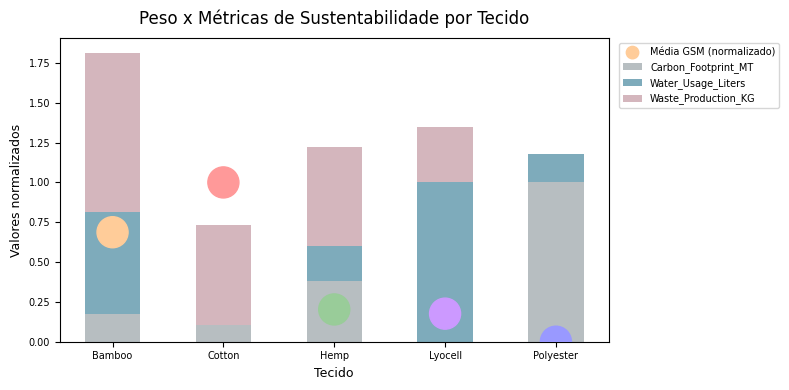

In [ ]:
metricas = ['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG']

# calculando média do peso por tecido
media_gsm = df_properties_limpo.groupby('tecido')['gsm'].mean().reset_index()

# calculando média das métricas por tecido e normalizar
pivot = df_sustainable_limpo.groupby('tecido')[metricas].mean()
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())
pivot_norm = pivot_norm.reset_index()

# normalizar gsm tambem para ficarem na mesma escala
media_gsm['gsm_norm'] = (media_gsm['gsm'] - media_gsm['gsm'].min()) / (media_gsm['gsm'].max() - media_gsm['gsm'].min())

fig, ax = plt.subplots(figsize=(8, 4))

# barras empilhadas por baixo
bottom = np.zeros(len(pivot_norm))
cores_metricas = ['#879499', '#28738f', '#b88692']
for j, metrica in enumerate(metricas):
    ax.bar(pivot_norm['tecido'], pivot_norm[metrica],
           bottom=bottom, alpha=0.6,
           color=cores_metricas[j], label=metrica, width=0.5)
    bottom += pivot_norm[metrica].values

# scatterplot por cima
ax.scatter(
    media_gsm['tecido'],
    media_gsm['gsm_norm'],
    color=[cores_tecidos[t] for t in media_gsm['tecido']],
    s=500,
    zorder=5,
    label='Média GSM (normalizado)'
)

ax.set_title('Peso x Métricas de Sustentabilidade por Tecido', fontsize=12, pad=10)
ax.set_xlabel('Tecido', fontsize=9)
ax.set_ylabel('Valores normalizados', fontsize=9)
ax.tick_params(labelsize=7)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=0.4)
plt.tight_layout()
plt.show()

- Quanto maior a coluna da sobreposição das métricas de sustentabilidade, menos sustentavel é o tecido

- A localização dos círculos mais abaixo indicam tecidos mais leves e os círculos mais acima na imagem os tecidos mais pesados.

- Tecido "Cotton" / Algodão não tem desperdício de água

- Tecido Polyester é o mais leve, porém é o que mais tem emissão de carbono.  

- Tecido Bamboo é o segundo mais pesado e tem maior impacto ambiental do que os outros.

### Criação de novo DataFrame a partir da coluna multivalorada "Garment_Types"

Esse processo envolve a técnica de pré processamento de dados "Feature Engineering", porém foi realizada na análise exploratória para que fosse possível a próxima análise.

In [ ]:
#transformando os dados de garment types em listas

df_garment = df_properties_limpo.copy()
df_garment['garment_types'] = df_garment['garment_types'].str.split(',')
df_garment = df_garment.explode('garment_types').reset_index(drop=True)

df_garment = df_garment[['tecido', 'garment_types']].rename(columns={'garment_types': 'garment_types'})

# verificando o funcionamento
print(f'Shape original: {df_properties.shape}')
print(f'Shape explodido: {df_garment.shape}')
df_garment.head()

Shape original: (1000, 12)
Shape explodido: (1701, 2)


,tecido,garment_types
0,Hemp,skirt
1,Hemp,coat
2,Hemp,jacket
3,Hemp,shirt
4,Hemp,sweater


### Garment types X Métricas de Sustentabilidade

#### Unindo as métricas de sustentabilidade ao dataframe df_garment

In [ ]:
df_garment_sust = df_garment.merge(
    df_sustainable_limpo[['tecido', 'Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG']],
    on='tecido',
    how='left'
)

# verificando funcionamento do código
print(df_garment_sust.shape)
df_garment_sust.head()

(1419162, 5)


,tecido,garment_types,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG
0,Hemp,skirt,345.64,1020265.49,18373.35
1,Hemp,skirt,122.81,2563102.30,44827.29
2,Hemp,skirt,413.27,3162662.08,2507.82
3,Hemp,skirt,437.75,2345334.52,96370.47
4,Hemp,skirt,184.09,2206445.72,13839.54


#### Cálculo da média de cada métrica de sustentabilidade em cada tipo de vestuário

In [ ]:
media_garment = df_garment_sust.groupby('garment_types')[['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG']].mean()
print(media_garment)
print(media_garment.shape)

               Carbon_Footprint_MT  Water_Usage_Liters  Waste_Production_KG
garment_types                                                              
activewear                  252.43          2538941.67             50012.64
bag                         252.44          2536934.64             50149.63
blanket                     252.38          2533901.06             50194.46
blouse                      252.61          2538569.66             50020.48
coat                        252.06          2536579.28             50186.18
dress                       252.61          2534071.20             50109.37
hat                         252.05          2539386.25             50157.98
hoodie                      252.53          2533732.56             50079.26
jacket                      252.43          2534483.09             50123.83
jeans                       252.30          2533964.58             50131.71
leggings                    252.63          2531027.40             50109.94
pants       

#### Gráfico com a soma das médias das métricas de sustentabilidade em cada tipo de vestuário

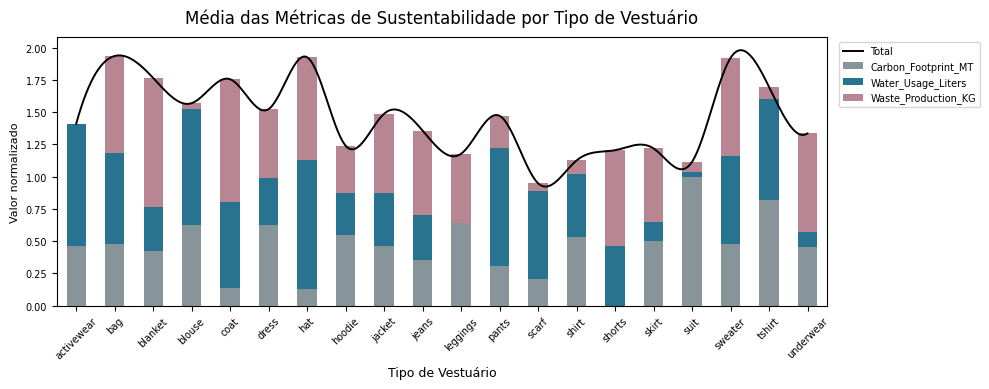

In [ ]:
metricas = ['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG']
cores_metricas = {
    'Carbon_Footprint_MT': '#879499',
    'Water_Usage_Liters': '#28738f',
    'Waste_Production_KG': '#b88692'
}

# normalizar
media_garment_norm = (media_garment - media_garment.min()) / (media_garment.max() - media_garment.min())

ax = media_garment_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 4),
    color=list(cores_metricas.values()),
    width=0.5
)

# calcular totais
totais = media_garment_norm.sum(axis=1)

# criar pontos interpolados
x = np.arange(len(totais))
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, totais.values, k=3)
y_smooth = spline(x_smooth)

# plotar linha suavizada
ax.plot(
    x_smooth,
    y_smooth,
    color='black',
    linewidth=1.4,
    linestyle='-',
    label='Total'
)

plt.title('Média das Métricas de Sustentabilidade por Tipo de Vestuário', fontsize=12, pad=10)
plt.xlabel('Tipo de Vestuário', fontsize=9)
plt.ylabel('Valor normalizado', fontsize=8)
plt.xticks(fontsize=7, rotation=45)
plt.yticks(fontsize=7)
plt.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Conclusão:
- Itens como Bag (Bolsas), Hat(Chapéu) e sweater tem maior impacto ambiental
- Scarf é o item com menor impacto
- Shorts não tem emissão de carbono. Coat(casaco) e Hat(Chapéu) emitem bem menos carbono que os outros.

## Evolução das métricas de sustentabilidade de cada tecido

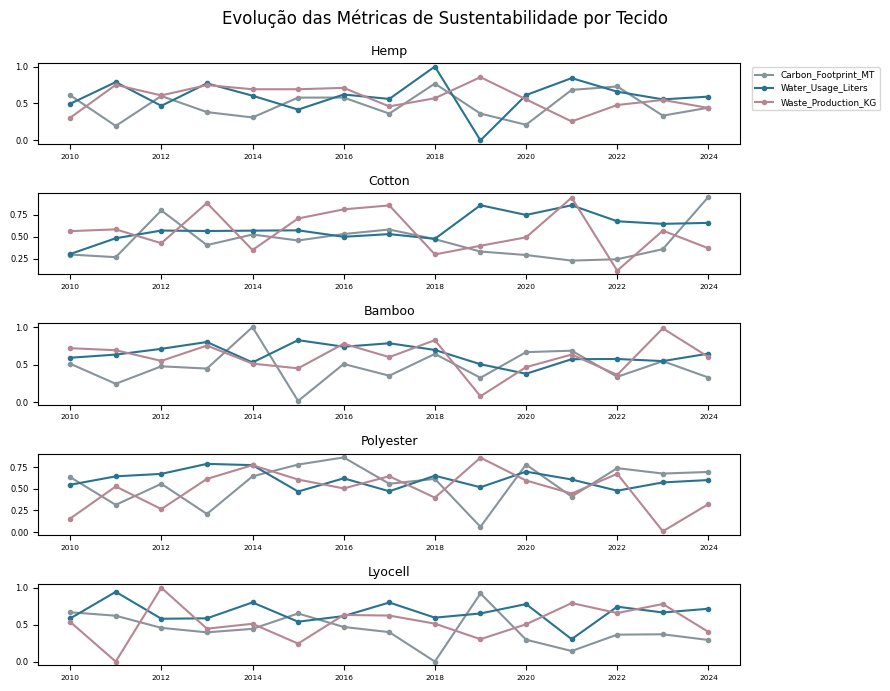

In [88]:
fig, axes = plt.subplots(5, 1, figsize=(9, 7))  # removido sharex=True

for i, tecido in enumerate(cores_tecidos.keys()):
    dados = media_ano[media_ano['tecido'] == tecido]

    for metrica, cor in cores_metricas.items():
        axes[i].plot(
            dados['Year'],
            dados[f'{metrica}_norm'],
            label=metrica,
            color=cor,
            linewidth=1.5,
            marker='o',
            markersize=3
        )
    axes[i].set_title(tecido, fontsize=9)
    axes[i].set_ylabel('', )
    axes[i].tick_params(axis='x', labelsize=5.4, rotation=0)  # ticks em todos
    axes[i].tick_params(axis='y', labelsize=6)

    if i == 0:
        axes[i].legend(fontsize=6.4, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Evolução das Métricas de Sustentabilidade por Tecido', fontsize=12)
plt.tight_layout()
plt.show()

## Métricas de sustentabilidade X Preço por País

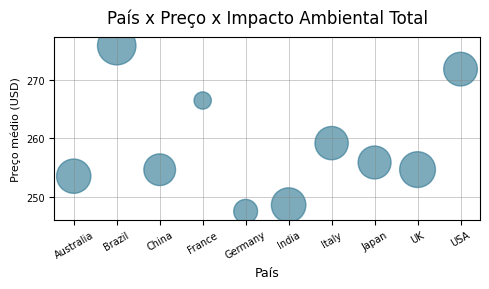

In [110]:
metricas = ['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Waste_Production_KG']

media_pais = df_sustainable_limpo.groupby('Country')[
    metricas + ['Average_Price_USD']
].mean().reset_index()

# normalizar cada metrica e somar
for metrica in metricas:
    media_pais[f'{metrica}_norm'] = (media_pais[metrica] - media_pais[metrica].min()) / (media_pais[metrica].max() - media_pais[metrica].min())

media_pais['soma_norm'] = media_pais[['Carbon_Footprint_MT_norm', 'Water_Usage_Liters_norm', 'Waste_Production_KG_norm']].sum(axis=1)

plt.figure(figsize=(5, 3))

plt.scatter(
    media_pais['Country'],
    media_pais['Average_Price_USD'],
    s=media_pais['soma_norm'] * 300,
    alpha=0.6,
    color='#28738f'
)

plt.grid(
    True,
    linestyle='-',
    linewidth=0.4,
    alpha=0.7,
    color='grey'
)
plt.title('País x Preço x Impacto Ambiental Total', fontsize=12, pad=10)
plt.xlabel('País', fontsize=9)
plt.ylabel('Preço médio (USD)', fontsize=8)
plt.xticks(fontsize=7, rotation=30)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

Vale ressaltar aqui que tecodos são vendidos por metro rolo

Porém, tecidos normalmente são vendidos em dezenas ou centenas de metros, e o preço normalmente consta como valor por metro do rolo de tecido.

Vale ressaltar também que a variavel largura do tecido também interfere nesse custo.

Portanto, é uma diferença significativa quando multiplicada pela metragem necessária.

# Respondendo as Hipóteses


## Hipótese 1

Alguns países tendem a produzir tecidos mais sustentáveis a um preço mais acessível do que outros?

## Hipótese 2

Existem tipos de tecido com índices de sustentabilidade consistentemente inferiores aos demais, independentemente do país e do ano?
Identificar um tecido como um outlier em termos de impacto ambiental pode acender um alerta para evitar o uso desse material.



## Hipótese 3
Tecidos mais leves tendem a ser mais sustentáveis do que tecidos mais pesados?
Entende a interferência da gramatura dos tecidos nos parâmetros de sustentabilidade.

Com o gráfico "Peso X Métricas de Sustentabilidade por tecido" o tecido "Bamboo" se destacou por ser o segundo mais pesado, e o que mais tem impacto ambiental, com grande descarte de resíduos.

## Hipótese 4
Existem linhas de produto com métricas de sustentabilidade significativamente inferiores às demais?

# Conclusão